In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [ ]:
# Load the data


# Extract the independent variable (Rotational Speed) and dependent variable (Torque)


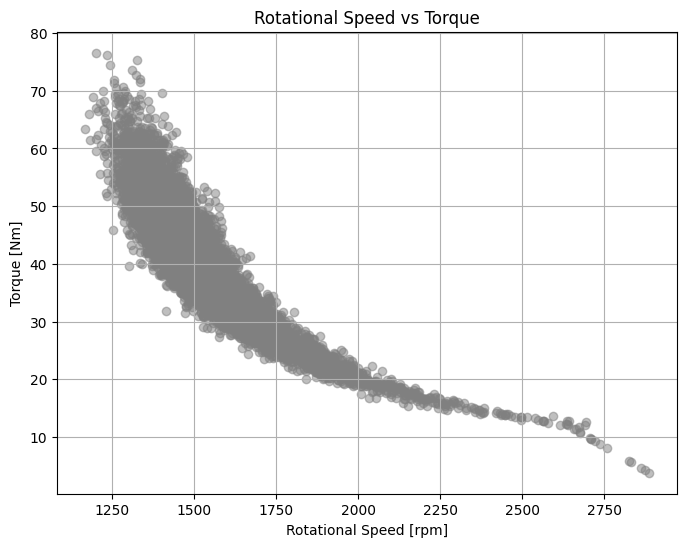

In [ ]:
# Scatter plot of Rotational Speed vs Torque
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color="gray", alpha=0.5)
plt.title("Rotational Speed vs Torque")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.grid(True)
plt.show()

After plotting the data, we might notice that the relationship between rotational speed and torque looks non-linear. The data points seem to follow a slight curve.


### Fit a Linear Regression Model

Even though the data looks curved, let's start with a **linear regression** model to see how well it performs. Linear regression assumes the relationship between the independent variable (rotational speed) and the dependent variable (torque) is a straight line.

#### Linear Regression Formula:
$$
y = \beta_0 + \beta_1 X
$$
Where:
- $ y $ is the predicted torque.
- $ X $ is the rotational speed.
- $ \beta_0 $ is the intercept.
- $ \beta_1 $ is the slope (rate of change in torque for a unit increase in speed).


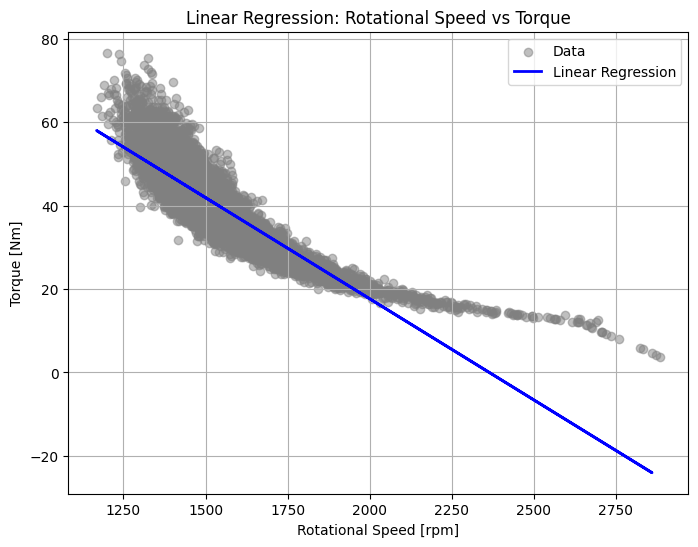

Linear Regression R-squared: 0.7569100243214557
Linear Regression Mean Squared Error (MSE): 23.957823414562316


In [ ]:
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

line_color = "choose a color??"
line_label = "label your line?"

# Plot the linear regression line
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color="gray", alpha=0.5, label="Data")
plt.plot(X_test, y_pred_linear, color=line_color, label=line_label, linewidth=2)
plt.title("Linear Regression: Rotational Speed vs Torque")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.legend()
plt.grid(True)
plt.show()

# Check performance of linear regression
r_squared_linear = linear_model.score(X_test, y_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)

print(f"Linear Regression R-squared: {r_squared_linear}")
print(f"Linear Regression Mean Squared Error (MSE): {mse_linear}")


### Observations from Linear Regression

- From the plot, we see that a **straight line** does not fit the data well. There appears to be curvature in the relationship.
- The **R-squared** value (how much variance in torque is explained by rotational speed) might be lower than desired, and the **MSE** (average squared difference between actual and predicted torque) might be relatively high.

### Polynomial Transformation

Since the linear model doesn't capture the curve well, we suspect a **non-linear relationship**. To model this, we can use **polynomial features**.

#### What Are Polynomial Features?

Polynomial regression allows us to capture curves by transforming the original feature $ X $ into higher-degree terms like $ X^2 $. However, **we are still applying linear regression** on these transformed features.

For example, a quadratic polynomial regression models the relationship as:
$$
y = \beta_0 + \beta_1 X + \beta_2 X^2
$$
Here, $ X^2 $ allows the model to capture the curvature in the data.

### Apply Polynomial Regression

We'll now transform the data by adding the square of the rotational speed as a feature, then fit a linear regression model to the transformed data.


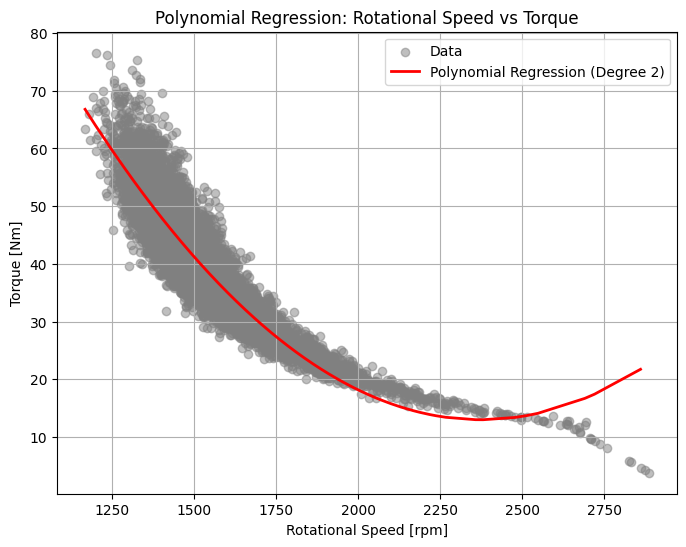

Polynomial Regression (Degree 2) R-squared: 0.8334589810683379
Polynomial Regression (Degree 2) Mean Squared Error (MSE): 16.41351237009566


In [ ]:
# Create polynomial features (degree 2 for quadratic regression)
poly = PolynomialFeatures(degree=??)
X_train_poly = poly.fit_transform(X_train)  # Transform the training data to include X^2
X_test_poly = poly.transform(X_test)  # Transform the test data to include X^2

# Train a linear regression model on the polynomial features


# Make predictions using the polynomial regression model


# Plot data points


#plot polynomial line

#missing lines
line_color = "choose a color??"
line_label = "label your line?"
plt.plot(X_sorted, y_pred_poly_sorted, color=line_color, label=line_label, linewidth=2)
plt.title("Polynomial Regression: Rotational Speed vs Torque")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.legend()
plt.grid(True)
plt.show()

# Check performance of polynomial regression


print(f"Polynomial Regression (Degree 2) R-squared: {r_squared_poly}")
print(f"Polynomial Regression (Degree 2) Mean Squared Error (MSE): {mse_poly}")


Exercise in class: Try using square ($X^2$) or cubic term ($X^3$) to model the relationship between Rotational Speed [rpm] and Torque [Nm].




## Explanation of Polynomial Features (example Degree 2)

In cell `HOF1Zb6mVk-P`, we used `PolynomialFeatures(degree=2)` to transform our original feature $X$ (Rotational Speed) into new features.

For a single feature $X$, a quadratic polynomial transformation creates the following new features:

1.  $X^0$: This is always equal to 1 and represents the intercept term ($\beta_0$) in the linear regression model.
2.  $X^1$: This is the original feature itself, used for the linear term ($\beta_1 X$).
3.  $X^2$: This is the square of the original feature, used for the quadratic term ($\beta_2 X^2$).

So, for each data point with a rotational speed $X$, the `PolynomialFeatures(degree=2)` object generates a new vector of features $[1, X, X^2]$.

When we then train a `LinearRegression` model on these transformed features, the model finds coefficients ($\beta_0, \beta_1, \beta_2$) for each of these terms:

$$
y = \beta_0 \cdot 1 + \beta_1 \cdot X + \beta_2 \cdot X^2
$$

This effectively fits a quadratic curve to the data, allowing the model to capture the slight curve observed in the initial scatter plot.

## Why Polynomial Regression is Still Linear Regression

It might seem counterintuitive, but polynomial regression is considered a form of **linear regression** because the model is still linear in terms of the **coefficients** ($\beta_0, \beta_1, \beta_2, \dots, \beta_n$).

Consider the polynomial regression equation with degree $n$:
$$
y = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_n X^n
$$

While the relationship between the independent variable $X$ and the dependent variable $y$ is non-linear (due to the $X^2, X^3$, etc. terms), the model is linear with respect to the $\beta$ coefficients.

Think of it this way: once you've created the polynomial features (like $X$, $X^2$, $X^3$), you are essentially fitting a standard linear regression model to these *new* features. The model is finding the best linear combination of these transformed features to predict $y$.

Let $Z_1 = X$, $Z_2 = X^2$, ..., $Z_n = X^n$. The equation becomes:
$$
y = \beta_0 + \beta_1 Z_1 + \beta_2 Z_2 + \dots + \beta_n Z_n
$$
This is the standard form of a multiple linear regression model, where $Z_1, Z_2, \dots, Z_n$ are the independent variables and $\beta_0, \beta_1, \dots, \beta_n$ are the coefficients.

Therefore, even though the plot of $y$ versus $X$ is curved, the process of finding the coefficients $\beta_i$ involves minimizing a linear combination of the transformed features, which is the core principle of linear regression.

## Create cubic polynomial features

### Subtask:
Transform the training and testing data to include $X^2$ and $X^3$ terms.


**Reasoning**:
Transform the training and testing data to include cubic terms using PolynomialFeatures.



In [ ]:
# Create polynomial features (degree 3 for cubic regression)


## Train a linear regression model

### Subtask:
Fit a linear regression model to the cubic polynomial features.


**Reasoning**:
Instantiate and train a linear regression model on the cubic polynomial features.



In [ ]:
# Train a linear regression model on the cubic polynomial features


LinearRegression()

## Make predictions

### Subtask:
Use the trained model to make predictions on the test set.


**Reasoning**:
Use the trained cubic model to make predictions on the test set and store the results.



In [ ]:
# Make predictions using the cubic polynomial regression model


## Plot the cubic regression curve

### Subtask:
Visualize the original data and the fitted cubic polynomial regression curve.


**Reasoning**:
Visualize the original data and the fitted cubic polynomial regression curve.



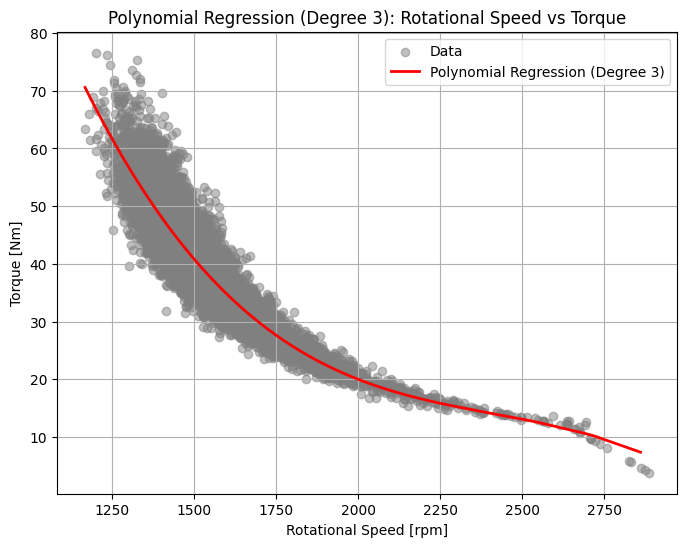

In [ ]:
# Create a new figure for the plot


# Scatter plot of the original data


# Sort the original test data


# Transform the sorted test data using the cubic polynomial features object


# Predict the torque values for the sorted, transformed test data


# Plot the predicted torque values against the sorted rotational speed values


# Add a title to the plot


# Label the x-axis


# Label the y-axis


# Add a legend


# Add a grid


# Display the plot


## Check performance

### Subtask:
Evaluate the performance of the cubic polynomial regression model using R-squared and Mean Squared Error (MSE).


**Reasoning**:
Calculate and print the R-squared and MSE for the cubic polynomial regression model.



In [ ]:
# Check performance of cubic polynomial regression



print(f"Polynomial Regression (Degree 3) R-squared: {r_squared_cubic}")
print(f"Polynomial Regression (Degree 3) Mean Squared Error (MSE): {mse_cubic}")

Polynomial Regression (Degree 3) R-squared: 0.8392600797883514
Polynomial Regression (Degree 3) Mean Squared Error (MSE): 15.841782917424558


## Summary:

### Data Analysis Key Findings

*   The training and testing data were transformed to include $X^2$ and $X^3$ terms for cubic polynomial regression using `PolynomialFeatures` with `degree=3`.
*   A `LinearRegression` model was trained on the transformed cubic polynomial features.
*   Predictions were made on the transformed test set using the trained cubic model.
*   The original data and the fitted cubic polynomial regression curve were visualized.
*   The performance of the cubic polynomial regression model was evaluated, yielding an R-squared of approximately 0.8393 and a Mean Squared Error (MSE) of approximately 15.8418.

### Insights or Next Steps

*   The cubic polynomial model appears to fit the data well, as indicated by the R-squared value.
*   Compare the performance of the cubic model with linear and quadratic models to determine the best degree of polynomial for this dataset.
